 # requirements

In [ ]:
import math
import itertools
import time
from datetime import timedelta, datetime
import numpy as np
import pandas as pd
#Graph
import seaborn  as sns
import matplotlib.pyplot as plt
# root path
import sys
import os

# Add the project root directory to sys.path
project_root = os.path.abspath(os.path.join(os.path.dirname(__file__), ".."))
sys.path.append(project_root)

# Now you can import from src
from src.app.utils import open_json

[nltk_data] Downloading package words to /home/usuario/nltk_data...
[nltk_data]   Package words is already up-to-date!


 # data

In [ ]:
df = pd.read_json('../data/data_jobs.json')
df

,vacancy_name,company,location,work_modality_english,seniority,link,job_function,industries,description,apply_link,publication_date,query_keyword,country,scraping_date
0,AI Engineer ID59360,AgileEngine,"Bogota, D.C., Capital District, Colombia",Full-time,Mid-Senior level,https://co.linkedin.com/jobs/view/ai-engineer-...,Information Technology,IT Services and IT Consulting,AgileEngine is an Inc. 5000 company that creat...,,2026-04-20,Cloud AI Engineer,colombia,2026-04-20
1,AI Engineer (Remote),Lumenalta,Colombia,Full-time,Mid-Senior level,https://co.linkedin.com/jobs/view/ai-engineer-...,"Engineering, Information Technology, and Consu...",IT Services and IT Consulting,"At Lumenalta, we partner with forward-thinking...",,2026-04-20,Cloud AI Engineer,colombia,2026-04-20
2,AI Engineer ID59360,AgileEngine,"Villavicencio, Meta, Colombia",Full-time,Mid-Senior level,https://co.linkedin.com/jobs/view/ai-engineer-...,Information Technology,IT Services and IT Consulting,AgileEngine is an Inc. 5000 company that creat...,,2026-04-20,Cloud AI Engineer,colombia,2026-04-20
3,AI Engineer ID59360,AgileEngine,"Barranquilla, Atlántico, Colombia",Full-time,Mid-Senior level,https://co.linkedin.com/jobs/view/ai-engineer-...,Information Technology,IT Services and IT Consulting,AgileEngine is an Inc. 5000 company that creat...,,2026-04-20,Cloud AI Engineer,colombia,2026-04-20
4,AI Engineer ID59360,AgileEngine,"Cali, Valle del Cauca, Colombia",Full-time,Mid-Senior level,https://co.linkedin.com/jobs/view/ai-engineer-...,Information Technology,IT Services and IT Consulting,AgileEngine is an Inc. 5000 company that creat...,,2026-04-20,Cloud AI Engineer,colombia,2026-04-20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8173,CONSULTOR CO GROW,PERCEPTIO S.A.S.,"Bogota, D.C., Capital District, Colombia",Full-time,Mid-Senior level,https://co.linkedin.com/jobs/view/consultor-co...,"Consulting, Information Technology, and Sales",IT Services and IT Consulting,"Somos una empresa Partner de Sap , nos especia...",None,2026-04-21,Gestión de programas de cooperación internacio...,Colombia,2026-04-21
8174,Assoc Regulatory Affairs Specialist,Medtronic,"Bogota, D.C., Capital District, Colombia",Full-time,Associate,https://co.linkedin.com/jobs/view/assoc-regula...,Legal,"Medical Equipment Manufacturing, Hospitals and...",At Medtronic you can begin a life-long career ...,None,2026-04-20,Gestión de programas de cooperación internacio...,Colombia,2026-04-21
8175,UX Researcher,ultima milla,Colombia,Full-time,Entry level,https://co.linkedin.com/jobs/view/ux-researche...,Information Technology,"Transportation, Logistics, Supply Chain and St...",Estamos innovando la logística y esto lo hemos...,None,2026-04-20,Gestión de programas de cooperación internacio...,Colombia,2026-04-21
8176,Director Aplicación Canales Digitales,Empresa Confidencial,Colombia,Full-time,Director,https://co.linkedin.com/jobs/view/director-apl...,"Business Development, Project Management, and ...",Banking and Financial Services,Nos encontramos en la búsqueda de un Director ...,None,2026-04-20,Gestión de programas de cooperación internacio...,Colombia,2026-04-21


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8178 entries, 0 to 8177
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   vacancy_name           8178 non-null   object
 1   company                8178 non-null   object
 2   location               8178 non-null   object
 3   work_modality_english  8178 non-null   object
 4   seniority              8178 non-null   object
 5   link                   8178 non-null   object
 6   job_function           7835 non-null   object
 7   industries             8178 non-null   object
 8   description            8178 non-null   object
 9   apply_link             38 non-null     object
 10  publication_date       8178 non-null   object
 11  query_keyword          8178 non-null   object
 12  country                8178 non-null   object
 13  scraping_date          8178 non-null   object
dtypes: object(14)
memory usage: 958.4+ KB


In [ ]:
df_types = pd.DataFrame(df.dtypes)
object_features = df_types[df_types[0] == 'object'].index.to_list()
object_features

['vacancy_name',
 'company',
 'location',
 'work_modality_english',
 'seniority',
 'link',
 'job_function',
 'industries',
 'description',
 'apply_link',
 'publication_date',
 'query_keyword',
 'country',
 'scraping_date']

In [ ]:
float_features = df_types[df_types[0] == 'float64'].index.to_list()
float_features

[]

In [ ]:
int_features = df_types[df_types[0] == 'int64'].index.to_list()
int_features

[]

In [ ]:
bool_features = df_types[df_types[0] == 'bool'].index.to_list()
bool_features

[]

In [ ]:
df.describe().T

,count,unique,top,freq
vacancy_name,8178,363,Analista de Negocios - Trabajo Remoto,281
company,8178,203,BairesDev,1634
location,8178,26,Colombia,4902
work_modality_english,8178,1,Full-time,8178
seniority,8178,7,Mid-Senior level,4513
link,8178,450,https://co.linkedin.com/jobs/view/virtual-assi...,108
job_function,7835,75,Information Technology,2761
industries,8178,91,IT Services and IT Consulting,2958
description,8178,382,AgileEngine is an Inc. 5000 company that creat...,294
apply_link,38,1,,38


In [ ]:
df[object_features].describe(include='all').T

,count,unique,top,freq
vacancy_name,8178,363,Analista de Negocios - Trabajo Remoto,281
company,8178,203,BairesDev,1634
location,8178,26,Colombia,4902
work_modality_english,8178,1,Full-time,8178
seniority,8178,7,Mid-Senior level,4513
link,8178,450,https://co.linkedin.com/jobs/view/virtual-assi...,108
job_function,7835,75,Information Technology,2761
industries,8178,91,IT Services and IT Consulting,2958
description,8178,382,AgileEngine is an Inc. 5000 company that creat...,294
apply_link,38,1,,38


In [ ]:
for col in object_features:
    print(f'------>{col} : {df[col].unique()}')
    print(f'------>{col} : {df[col].value_counts(dropna=False)}')

------>vacancy_name : ['AI Engineer ID59360' 'AI Engineer (Remote)' 'Data Scientist'
 'AI & Software Engineer Tech Lead'
 'Lead Observability Engineer (US Time Zone)' 'Ingeniero Sr. de IA'
 'Ingeniero Salesforce - Trabajo Remoto' 'Engineer Highways'
 'Platform Database Engineer (MONGO DB)'
 'Sr Full Stack & AI-Augmented Development' 'Full Stack Engineer'
 'Senior SDET ID57977' 'Senior DevOps Engineer'
 'Senior Software Engineer || C# - Windows Desktop | LATAM'
 'PHP Laravel & Vue Developer' 'Senior Software Engineer in Test ID57977'
 'Platform Engineer (CI)'
 'AEM Edge Delivery Services (EDS) Backend Developer' 'Head of Growth'
 'Billing & Operations Specialist' 'People & Talent Partner'
 'Python Backend Engineer ID59360' 'Virtual Assistant'
 'Python Developer / Investigación y Desarrollo - Trabajo Remoto'
 'AZURE - Cloud Engineer, Infrastructure Engineer o DevOps Engineer'
 'Científico de Datos Senior - Trabajo Remoto'
 'Desarrollador Java Junior - Trabajo Remoto' 'AI Prompt Engineer'

 ## null values visualization

Text(50.722222222222214, 0.5, 'Fila')

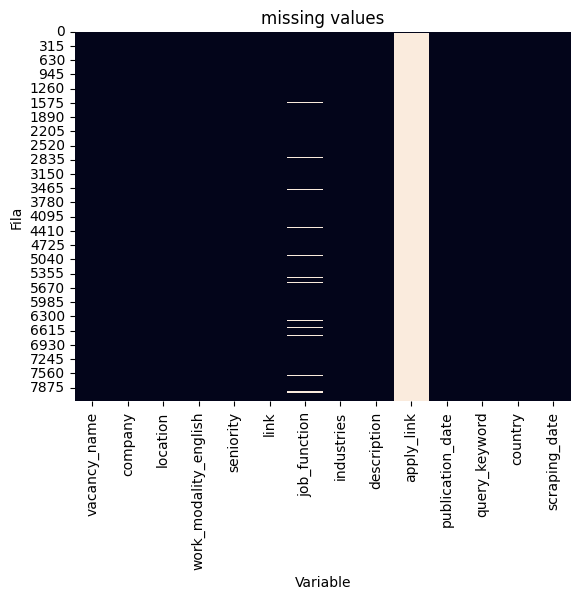

In [ ]:
sns.heatmap(df.isnull(), cbar=False)
plt.title("missing values")
plt.xlabel('Variable')
plt.ylabel('Fila')

 # categorical variables

Text(0.5, 1.0, "'industries'")

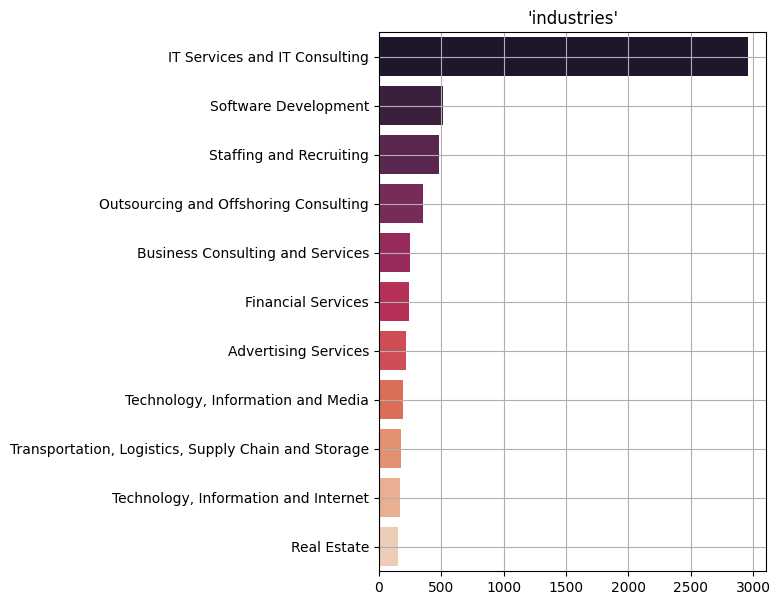

In [ ]:
plt.figure(figsize=(5,7))
a = pd.DataFrame(df['industries'].value_counts()[:11])
y = np.array(list(a.index))
x = np.array(list(a['count']))
sns.barplot(x=x, y=y, palette="rocket", hue=y, legend=False)
plt.grid(True)
plt.title("'industries'")

Text(0.5, 1.0, "'company'")

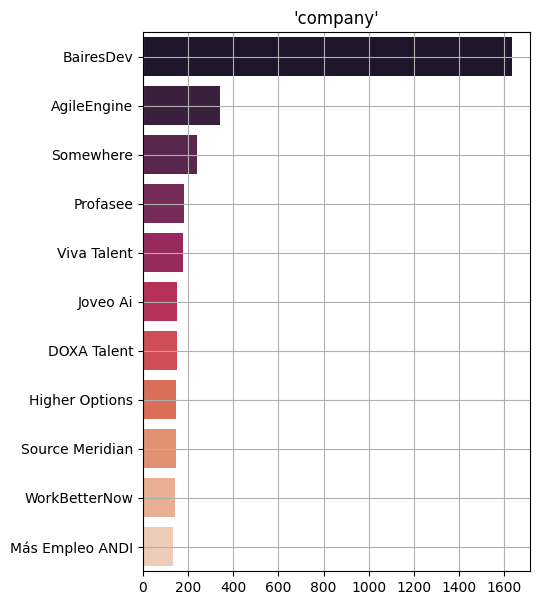

In [ ]:
plt.figure(figsize=(5,7))
a = pd.DataFrame(df['company'].value_counts()[:11])
y = np.array(list(a.index))
x = np.array(list(a['count']))
sns.barplot(x=x, y=y, palette="rocket", hue=y, legend=False)
plt.grid(True)
plt.title("'company'")

Text(0.5, 1.0, "'location'")

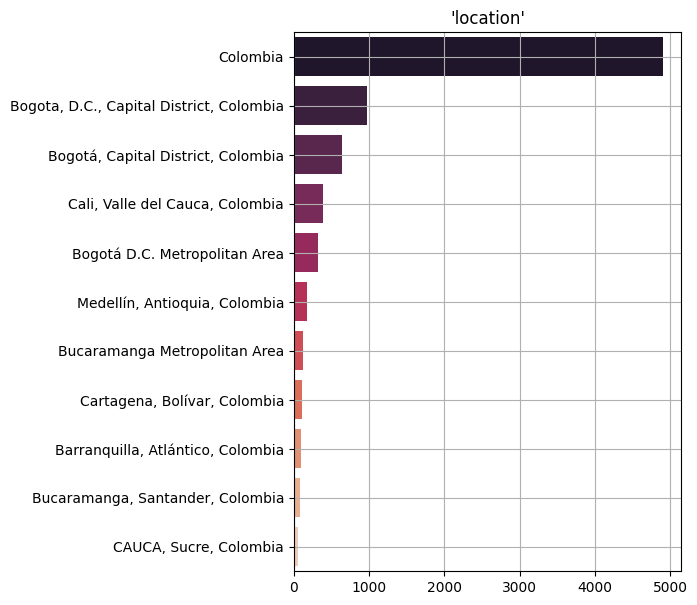

In [ ]:
plt.figure(figsize=(5,7))
a = pd.DataFrame(df['location'].value_counts()[:11])
y = np.array(list(a.index))
x = np.array(list(a['count']))
sns.barplot(x=x, y=y, palette="rocket", hue=y, legend=False)
plt.grid(True)
plt.title("'location'")

Text(0.5, 1.0, "'work_modality_english'")

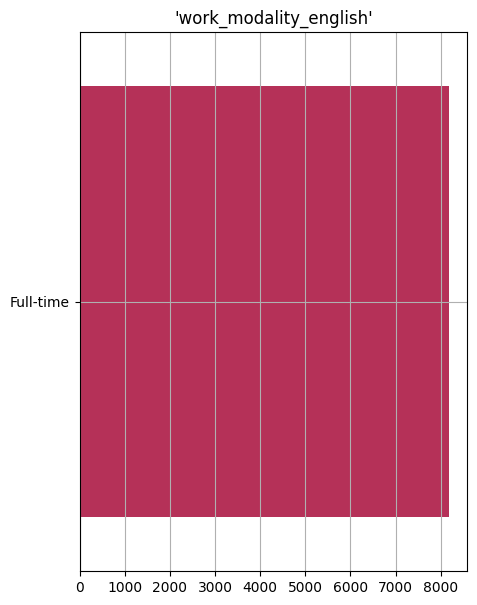

In [ ]:
plt.figure(figsize=(5,7))
a = pd.DataFrame(df['work_modality_english'].value_counts()[:11])
y = np.array(list(a.index))
x = np.array(list(a['count']))
sns.barplot(x=x, y=y, palette="rocket", hue=y, legend=False)
plt.grid(True)
plt.title("'work_modality_english'")

Text(0.5, 1.0, "'seniority'")

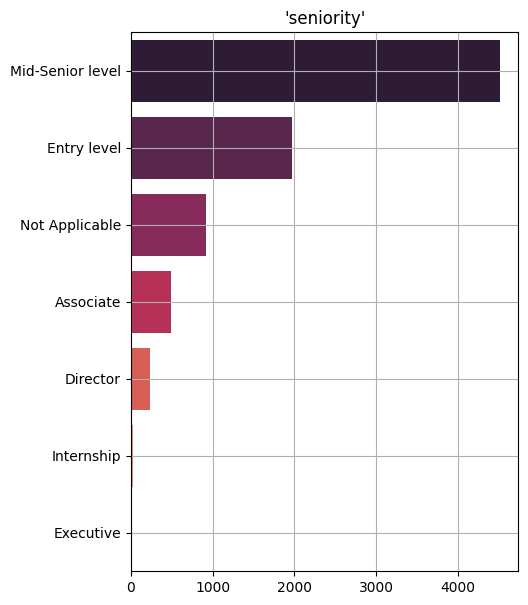

In [ ]:
plt.figure(figsize=(5,7))
a = pd.DataFrame(df['seniority'].value_counts()[:11])
y = np.array(list(a.index))
x = np.array(list(a['count']))
sns.barplot(x=x, y=y, palette="rocket", hue=y, legend=False)
plt.grid(True)
plt.title("'seniority'")

Text(0.5, 1.0, "'publication_date'")

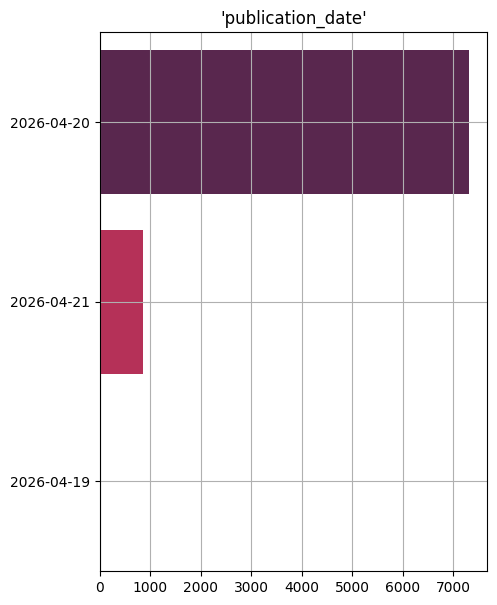

In [ ]:
plt.figure(figsize=(5,7))
a = pd.DataFrame(df['publication_date'].value_counts()[:11])
y = np.array(list(a.index))
x = np.array(list(a['count']))
sns.barplot(x=x, y=y, palette="rocket", hue=y, legend=False)
plt.grid(True)
plt.title("'publication_date'")

 # knowledge based filters

In [ ]:
job_seeker = open_json('../data/job_seekers.json')
job_seeker[0].keys()
seniority_criteria = job_seeker[0]['seniority']
location_criteria = job_seeker[0]['location']
work_modality_criteria = job_seeker[0]['work_modality_english']
excluded_companies = ["BairesDev"]

In [ ]:
df_filtered = df[
    (df["seniority"].isin(seniority_criteria)) &  # Filter by seniority
    (df["location"].isin(location_criteria)) &    # Filter by location
    (df["work_modality_english"].isin(work_modality_criteria)) &  # Filter by work modality
    (~df["company"].isin(excluded_companies))     # Exclude specified companies
].copy()
df_filtered.shape

(4869, 14)

 # categorical variables

Text(0.5, 1.0, "'company'")

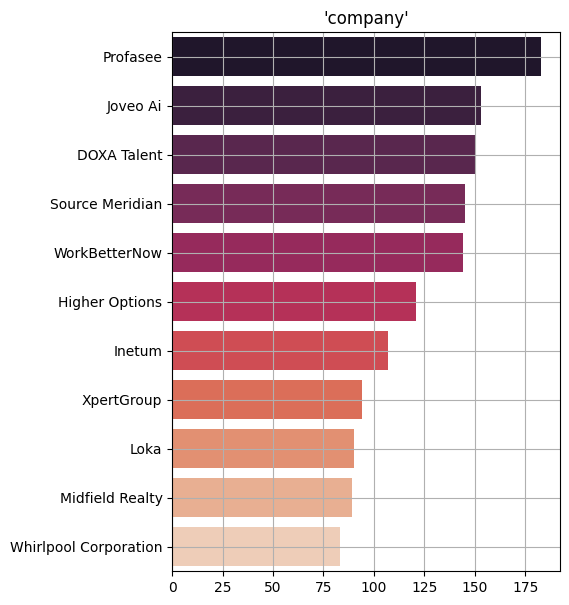

In [ ]:
plt.figure(figsize=(5,7))
a = pd.DataFrame(df_filtered['company'].value_counts()[:11])
y = np.array(list(a.index))
x = np.array(list(a['count']))
sns.barplot(x=x, y=y, palette="rocket", hue=y, legend=False)
plt.grid(True)
plt.title("'company'")

Text(0.5, 1.0, "'location'")

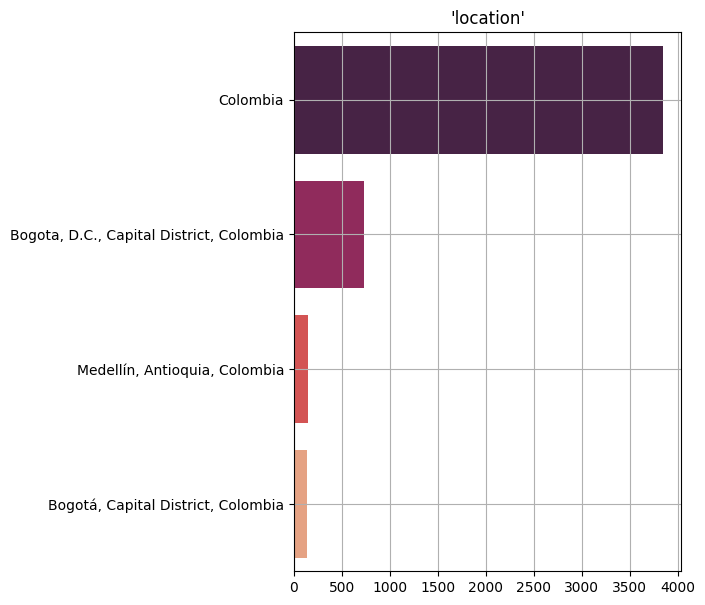

In [ ]:
plt.figure(figsize=(5,7))
a = pd.DataFrame(df_filtered['location'].value_counts()[:11])
y = np.array(list(a.index))
x = np.array(list(a['count']))
sns.barplot(x=x, y=y, palette="rocket", hue=y, legend=False)
plt.grid(True)
plt.title("'location'")

Text(0.5, 1.0, "'work_modality_english'")

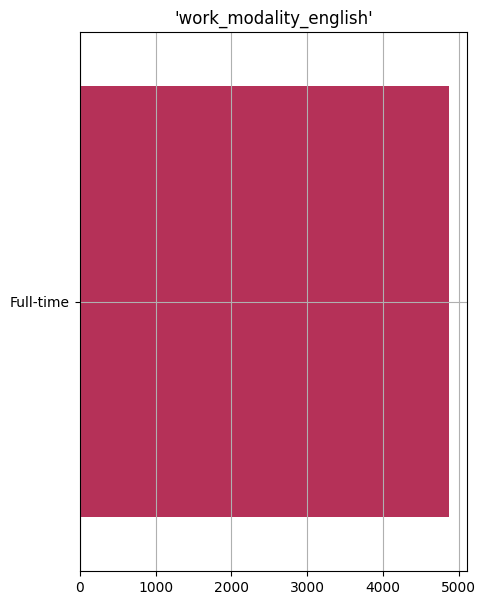

In [ ]:
plt.figure(figsize=(5,7))
a = pd.DataFrame(df_filtered['work_modality_english'].value_counts()[:11])
y = np.array(list(a.index))
x = np.array(list(a['count']))
sns.barplot(x=x, y=y, palette="rocket", hue=y, legend=False)
plt.grid(True)
plt.title("'work_modality_english'")

Text(0.5, 1.0, "'seniority'")

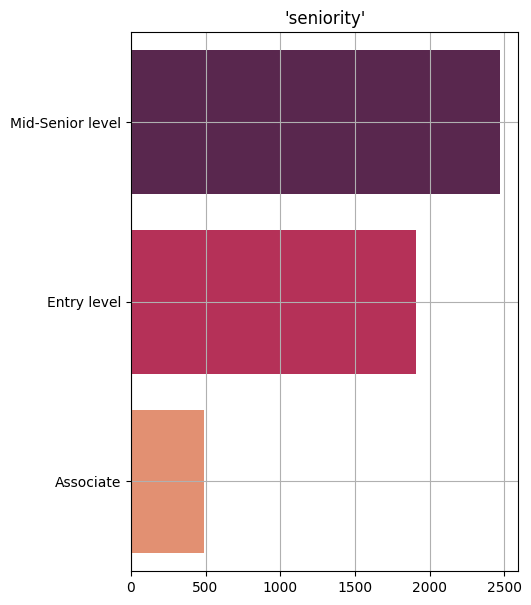

In [ ]:
plt.figure(figsize=(5,7))
a = pd.DataFrame(df_filtered['seniority'].value_counts()[:11])
y = np.array(list(a.index))
x = np.array(list(a['count']))
sns.barplot(x=x, y=y, palette="rocket", hue=y, legend=False)
plt.grid(True)
plt.title("'seniority'")

Text(0.5, 1.0, "'publication_date'")

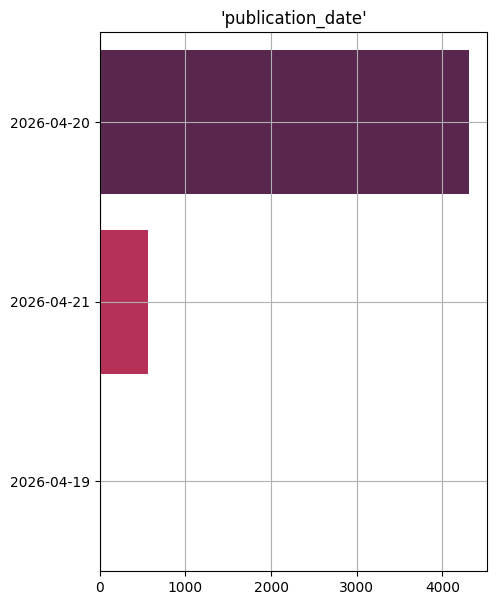

In [ ]:
plt.figure(figsize=(5,7))
a = pd.DataFrame(df_filtered['publication_date'].value_counts()[:11])
y = np.array(list(a.index))
x = np.array(list(a['count']))
sns.barplot(x=x, y=y, palette="rocket", hue=y, legend=False)
plt.grid(True)
plt.title("'publication_date'")

Text(0.5, 1.0, "'vacancy_name'")

/home/usuario/Documents/jobbot/venv_jobbot/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/usuario/Documents/jobbot/venv_jobbot/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


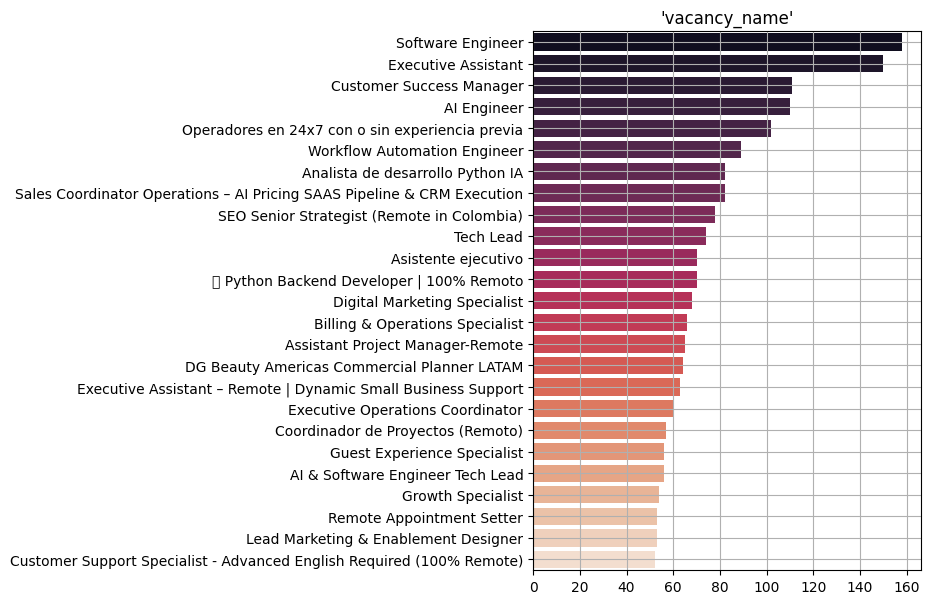

In [ ]:
plt.figure(figsize=(5,7))
df = df_filtered[df_filtered['publication_date'] > (datetime.now() - timedelta(days=3)).strftime('%Y-%m-%d')]
a = pd.DataFrame(df['vacancy_name'].value_counts()[:25])
y = np.array(list(a.index))
x = np.array(list(a['count']))
sns.barplot(x=x, y=y, palette="rocket", hue=y, legend=False)
plt.grid(True)
plt.title("'vacancy_name'")

 # skills

In [ ]:
df_skills = pd.read_json('../data/general_skills.json')
print(df_skills.shape)
df_skills['skills'] = df_skills['skills'].apply(lambda x: x.lower())
df_skills.drop_duplicates(inplace=True)
print(df_skills.shape)
df_skills.to_json('../data/general_skills.json')

(462, 1)
(462, 1)


 # Job title description file

In [ ]:
industries = [
    'IT Services and IT Consulting',
    'Software Development',
    'Technology, Information and Internet',
    'Business Consulting and Services'
]
df_summary = df_filtered[df_filtered['industries'].isin(industries)][['vacancy_name','description']][:1000].copy()
print(df_summary.shape)
df_summary.to_json('../data/vacancy_name_description.json')

(1000, 2)
